# **Análise e exploração de dados de jogos da Steam**

In [ ]:
import pandas as pd
import seaborn as sns
import plotly.express as px

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving steam_games_dataset.csv to steam_games_dataset (1).csv


In [ ]:
df = pd.read_csv("steam_games_dataset.csv")

df.head()

,appid,name,developer,publisher,score_rank,positive,negative,userscore,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu
0,730,Counter-Strike: Global Offensive,Valve,Valve,NaN,7642084,1173003,0,"100,000,000 .. 200,000,000",33852,708,6645,301,0,0,0,1013936
1,1172470,Apex Legends,Respawn,Electronic Arts,NaN,668053,326926,0,"100,000,000 .. 200,000,000",10506,496,935,246,0,0,0,124262
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",NaN,1520457,1037487,0,"100,000,000 .. 200,000,000",23165,717,5622,261,0,0,0,314682
3,1623730,Palworld,Pocketpair,Pocketpair,NaN,358266,22443,0,"50,000,000 .. 100,000,000",3854,835,2213,257,2999,2999,0,18028
4,440,Team Fortress 2,Valve,Valve,NaN,1044264,117208,0,"50,000,000 .. 100,000,000",21244,736,4262,102,0,0,0,43819


### Pergunta 1:

Jogos com mais jogadores simultâneos recebem mais avaliações positivas?

### Pergunta 2

Quais jogos possuem mais jogadores simultâneos na plataforma?

### Pergunta 3:

Existe relação entre preço do jogo e número de donos?

### Pergunta 4:

Jogos com maior tempo médio jogado tendem a ter avaliações melhores?

## Exploração inicial, gráficos e comentários


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   appid            10000 non-null  int64  
 1   name             10000 non-null  object 
 2   developer        9967 non-null   object 
 3   publisher        9946 non-null   object 
 4   score_rank       5 non-null      float64
 5   positive         10000 non-null  int64  
 6   negative         10000 non-null  int64  
 7   userscore        10000 non-null  int64  
 8   owners           10000 non-null  object 
 9   average_forever  10000 non-null  int64  
 10  average_2weeks   10000 non-null  int64  
 11  median_forever   10000 non-null  int64  
 12  median_2weeks    10000 non-null  int64  
 13  price            10000 non-null  int64  
 14  initialprice     10000 non-null  int64  
 15  discount         10000 non-null  int64  
 16  ccu              10000 non-null  int64  
dtypes: float64(1)

In [ ]:
df.describe()

,appid,score_rank,positive,negative,userscore,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu
count,1.000000e+04,5.0,1.000000e+04,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04
mean,9.008700e+05,99.0,1.214202e+04,1.948096e+03,0.036000,1023.689500,112.496300,515.001700,118.949000,1131.326700,1284.141500,8.675800,5.643178e+02
std,7.290494e+05,1.0,9.536926e+04,1.812977e+04,1.671581,4193.287962,638.473189,3508.429257,707.962801,1299.903805,1364.327698,23.476133,1.128781e+04
min,1.000000e+01,98.0,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,3.365875e+05,98.0,4.310000e+02,1.100000e+02,0.000000,145.000000,0.000000,79.750000,0.000000,99.000000,199.000000,0.000000,0.000000e+00
50%,6.551300e+05,99.0,1.514500e+03,2.950000e+02,0.000000,310.000000,0.000000,210.000000,0.000000,719.000000,999.000000,0.000000,5.000000e+00
75%,1.333238e+06,100.0,4.996750e+03,8.712500e+02,0.000000,817.250000,6.000000,406.000000,6.000000,1799.000000,1999.000000,0.000000,4.500000e+01
max,3.605460e+06,100.0,7.642084e+06,1.173003e+06,95.000000,263340.000000,20080.000000,269193.000000,20080.000000,14999.000000,14999.000000,95.000000,1.013936e+06


In [ ]:
df.isnull().sum()

,0
appid,0
name,0
developer,33
publisher,54
score_rank,9995
positive,0
negative,0
userscore,0
owners,0
average_forever,0


In [ ]:
df['owners'] = df['owners'].str.replace(',', '')
df['owners'] = pd.to_numeric(df['owners'], errors='coerce')

In [ ]:
df['approval_rate'] = df['positive'] / (df['positive'] + df['negative'])

<Axes: xlabel='positive', ylabel='ccu'>

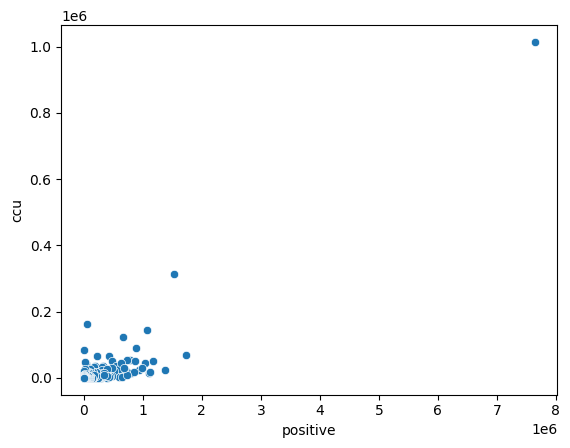

In [ ]:
#Gráfico 1 relacionado a pergunta 1.

sns.scatterplot(data=df, x="positive", y="ccu")

Escolhi no gráfico 1 um de dispersão porque ele permite visualizar a relação entre duas variáveis numéricas (avaliações positivas e jogadores simultâneos).

Existe uma relação positiva entre avaliações positivas e número de jogadores simultâneos, indicando que jogos mais bem avaliados tendem a ser mais populares. No entanto, poucos jogos concentram valores muito altos.

<Axes: xlabel='ccu', ylabel='name'>

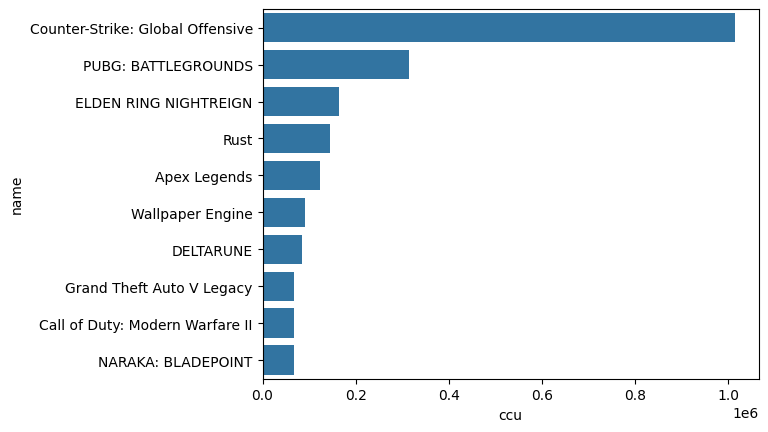

In [ ]:
# Gráfico 2 relacionado a pergunta 2.


top_games = df.sort_values("ccu", ascending=False).head(10)


sns.barplot(data=top_games, x="ccu", y="name")

Escolhi no gráfico 2 o de barras porque ele é ideal para comparar valores entre categorias, neste caso os jogos com mais jogadores simultâneos.

Poucos jogos concentram a maior parte dos jogadores simultâneos, com grande destaque para os primeiros colocados, evidenciando alta concentração de popularidade.

<Axes: xlabel='price', ylabel='Count'>

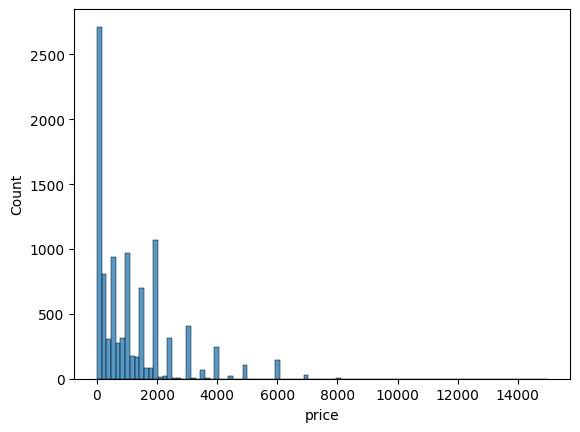

In [ ]:
# Gráfico 3 relacionado a pergunta 3.

sns.histplot(df["price"])

Escolhi o histograma porque ele permite analisar a distribuição dos preços dos jogos e identificar padrões de concentração.

A maioria dos jogos possui preços baixos ou gratuitos, o que dificulta identificar uma relação clara entre preço e número de donos apenas com esse gráfico.

<Axes: >

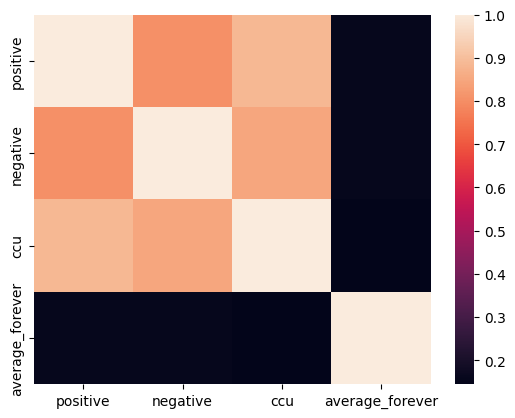

In [ ]:
# Gráfico 4 relacionado com a pergunta 4.


corr = df[['positive', 'negative', 'ccu', 'average_forever']].corr()

sns.heatmap(corr)

Escolhi o heatmap porque ele facilita a visualização das correlações entre múltiplas variáveis ao mesmo tempo.

Observa-se correlação positiva entre tempo jogado e avaliações positivas, indicando que jogos mais engajantes e imersivos tendem a ser melhor avaliados.

### *Conclusão final*

A análise indica que jogos mais populares e com maior engajamento tendem a receber melhores avaliações, mostrando uma relação entre experiência do usuário e número de jogadores.

Além disso, a maioria dos jogos possui preços baixos ou gratuitos, enquanto poucos títulos concentram grande parte dos jogadores, evidenciando a competitividade da plataforma.
